In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Myocardial"
file_count = len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])
print(f"The number of files for {folder_path} \n is: {file_count}")

The number of files for /content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Myocardial 
 is: 224


In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Normal"
file_count = len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])
print(f"The number of files for {folder_path} \n is: {file_count}")

The number of files for /content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Normal 
 is: 224


In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Myocardial"
file_count = len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])
print(f"The number of files for {folder_path} \n is: {file_count}")

The number of files for /content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Myocardial 
 is: 56


In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Normal"
file_count = len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])
print(f"The number of files for {folder_path} \n is: {file_count}")

The number of files for /content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Normal 
 is: 56


In [ ]:
import matplotlib.pyplot as plt
from scipy.io import wavfile
import numpy as np

In [ ]:
wav_idx = 0

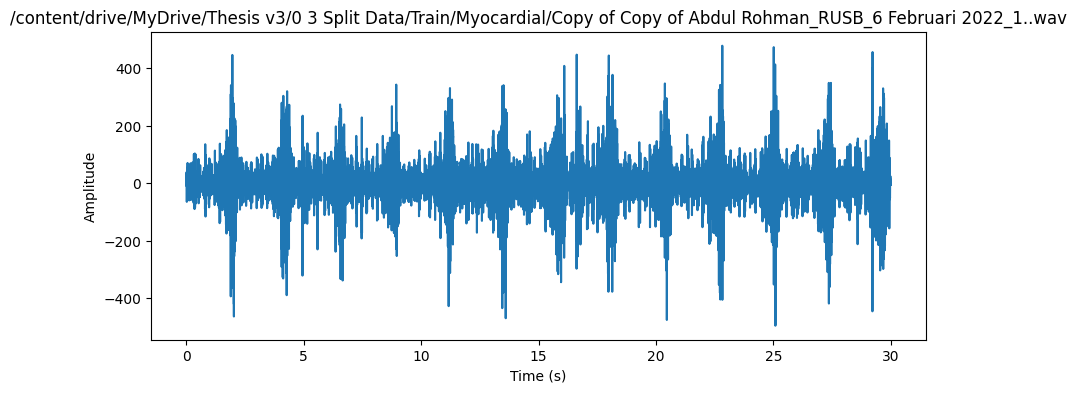

In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Myocardial"
# Get a list of all files in the folder
all_files = os.listdir(folder_path)
# Filter for .wav files
wav_files = [f for f in all_files if f.endswith('.wav')]

if wav_files:
    # Take the second wav file found (index 1)
    file_to_plot = os.path.join(folder_path, wav_files[wav_idx])

    # Read the wav file
    samplerate, data = wavfile.read(file_to_plot)

    # Create a time array in seconds
    time = np.arange(0, len(data)) / samplerate

    # Plot the data
    plt.figure(figsize=(10, 4))
    plt.plot(time, data)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(file_to_plot)
    plt.show()
else:
    print(f"No .wav files found in {folder_path}")

In [ ]:
pip install noisereduce

In [ ]:
import numpy as np
import librosa
import noisereduce as nr
import pywt
from scipy.stats import skew, kurtosis, iqr

In [ ]:
def extract_mids_features(audio_path):

    y, sr = librosa.load(audio_path, sr=None)

    y_denoised = nr.reduce_noise(y=y, sr=sr, stationary=True, time_mask_smooth_ms=150)

    features = {}

    def get_stats(data, prefix, stat_list):
        data = data.flatten()
        res = {}
        n_bins=70
        if 'mean' in stat_list: res[f'{prefix}_mean'] = np.mean(data)
        if 'std' in stat_list: res[f'{prefix}_std'] = np.std(data)
        if 'max' in stat_list: res[f'{prefix}_max'] = np.max(data)
        if 'min' in stat_list: res[f'{prefix}_min'] = np.min(data)
        if 'median' in stat_list: res[f'{prefix}_median'] = np.median(data)
        if 'var' in stat_list: res[f'{prefix}_var'] = np.var(data)
        if 'skew' in stat_list: res[f'{prefix}_skew'] = skew(data)
        if 'kurt' in stat_list: res[f'{prefix}_kurtosis'] = kurtosis(data)
        if 'q1' in stat_list: res[f'{prefix}_q1'] = np.percentile(data, 25)
        if 'q3' in stat_list: res[f'{prefix}_q3'] = np.percentile(data, 75)
        if 'iqr' in stat_list: res[f'{prefix}_iqr'] = iqr(data)
        if 'range' in stat_list: res[f'{prefix}_range'] = np.max(data) - np.min(data)
        return res


    coeffs = pywt.wavedec(y_denoised, 'db6', level=4)
    cA4 = coeffs[0]
    dwt_stats = ['mean', 'max', 'min', 'median', 'q1', 'q3', 'iqr']
    features.update(get_stats(cA4, 'dwt', dwt_stats))

    n_fft = int(0.025 * sr)
    mfcc = librosa.feature.mfcc(y=y_denoised, sr=sr, n_mfcc=13, n_fft=n_fft, hop_length=n_fft//2)
    mfcc_stats = ['mean', 'std', 'max', 'median', 'var', 'skew', 'q1', 'q3', 'iqr', 'range', 'kurt']
    features.update(get_stats(mfcc, 'mfcc', mfcc_stats))

    cqt_complex = librosa.cqt(y_denoised, sr=sr, n_bins=70)
    cqt_mag = np.abs(cqt_complex)
    cqt_stats = ['mean', 'min', 'median', 'var', 'q1', 'q3', 'iqr', 'range', 'kurt']
    features.update(get_stats(cqt_mag, 'cqt', cqt_stats))

    chroma = librosa.feature.chroma_stft(y=y_denoised, sr=sr)
    chroma_stats = ['mean', 'std', 'max', 'min', 'median', 'var', 'skew', 'q1', 'q3', 'iqr', 'range', 'kurt']
    features.update(get_stats(chroma, 'chroma', chroma_stats))

    rms = librosa.feature.rms(y=y_denoised)
    rms_stats = ['mean', 'std', 'max', 'min', 'median', 'var', 'skew', 'q1', 'q3', 'range', 'kurt']
    features.update(get_stats(rms, 'rms', rms_stats))

    energy = np.abs(y_denoised) ** 2
    probability_distribution = energy / np.sum(energy)

    probability_distribution = probability_distribution[probability_distribution > 0]
    shannon_entropy = -np.sum(probability_distribution * np.log(probability_distribution))
    features['shannon_entropy'] = shannon_entropy


    return features

In [ ]:
file_path = file_to_plot
data = extract_mids_features(file_path)
print(f"Extracted {len(data)} features.")
print(data)

Extracted 51 features.
{'dwt_mean': np.float32(1.2067496e-08), 'dwt_max': np.float32(0.013878082), 'dwt_min': np.float32(-0.014668401), 'dwt_median': np.float32(-1.5006444e-11), 'dwt_q1': np.float32(-2.8374778e-05), 'dwt_q3': np.float32(2.6274009e-05), 'dwt_iqr': np.float64(5.46487872270518e-05), 'mfcc_mean': np.float32(-81.47304), 'mfcc_std': np.float32(295.34805), 'mfcc_max': np.float32(152.37076), 'mfcc_median': np.float32(0.0), 'mfcc_var': np.float32(87230.48), 'mfcc_skew': np.float32(-3.1632807), 'mfcc_kurtosis': np.float32(8.0817175), 'mfcc_q1': np.float32(-3.0194807), 'mfcc_q3': np.float32(3.4106922), 'mfcc_iqr': np.float64(6.430172920227051), 'mfcc_range': np.float32(1283.7416), 'cqt_mean': np.float32(0.00035192477), 'cqt_min': np.float32(4.0083276e-15), 'cqt_median': np.float32(1.9746462e-06), 'cqt_var': np.float32(1.3052812e-06), 'cqt_kurtosis': np.float32(42.426895), 'cqt_q1': np.float32(8.052695e-08), 'cqt_q3': np.float32(9.641051e-05), 'cqt_iqr': np.float64(9.6329985973753

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [ ]:
data

{'dwt_mean': np.float32(1.2067496e-08),
 'dwt_max': np.float32(0.013878082),
 'dwt_min': np.float32(-0.014668401),
 'dwt_median': np.float32(-1.5006444e-11),
 'dwt_q1': np.float32(-2.8374778e-05),
 'dwt_q3': np.float32(2.6274009e-05),
 'dwt_iqr': np.float64(5.46487872270518e-05),
 'mfcc_mean': np.float32(-81.47304),
 'mfcc_std': np.float32(295.34805),
 'mfcc_max': np.float32(152.37076),
 'mfcc_median': np.float32(0.0),
 'mfcc_var': np.float32(87230.48),
 'mfcc_skew': np.float32(-3.1632807),
 'mfcc_kurtosis': np.float32(8.0817175),
 'mfcc_q1': np.float32(-3.0194807),
 'mfcc_q3': np.float32(3.4106922),
 'mfcc_iqr': np.float64(6.430172920227051),
 'mfcc_range': np.float32(1283.7416),
 'cqt_mean': np.float32(0.00035192477),
 'cqt_min': np.float32(4.0083276e-15),
 'cqt_median': np.float32(1.9746462e-06),
 'cqt_var': np.float32(1.3052812e-06),
 'cqt_kurtosis': np.float32(42.426895),
 'cqt_q1': np.float32(8.052695e-08),
 'cqt_q3': np.float32(9.641051e-05),
 'cqt_iqr': np.float64(9.63299859737

In [ ]:
import pandas as pd

df = pd.DataFrame([data])
print("DataFrame created from extracted features:")
display(df)

DataFrame created from extracted features:


,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_max,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,0.001483,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.86671


In [ ]:
import pandas as pd

# Convert the 'data' dictionary to a single-row DataFrame
new_row_df = pd.DataFrame([data])

# Append the new row to the existing DataFrame 'df'
df = pd.concat([df, new_row_df], ignore_index=True)

print("Updated DataFrame after appending 'data':")
display(df)

Updated DataFrame after appending 'data':


,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_max,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,0.001483,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.86671
1,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,0.001483,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.86671


In [ ]:
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_max,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,0.001483,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.86671


In [ ]:
df = pd.DataFrame()

In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Myocardial"
all_files = os.listdir(folder_path)
wav_files = [f for f in all_files if f.endswith('.wav')]

for i in range(len(all_files)):
  if wav_files:
      file_to_plot = os.path.join(folder_path, wav_files[i])

      data = extract_mids_features(file_to_plot)
      print(f"Extracted {len(data)} features for {wav_files[i]}.")

      new_row_df = pd.DataFrame([data])

      df = pd.concat([df, new_row_df], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Extracted 51 features for Copy of Copy of Abdul Rohman_RUSB_6 Februari 2022_1..wav.
Extracted 51 features for Copy of Copy of Ating Cartim_LUSB_16 Maret 2022.wav.
Extracted 51 features for Copy of APEX.wav.
Extracted 51 features for Copy of LUSB.wav.
Extracted 51 features for Copy of LLSB.wav.
Extracted 51 features for Copy of Copy of Pirman Pirman Syah_LLSB_8 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Odang Sobali_RUSB_4 Juli 2022_1.wav.
Extracted 51 features for Copy of Copy of Nurhayati_RUSB_19 Agustus 2022_1.wav.
Extracted 51 features for Copy of Copy of Odang Sobali_APEX_4 Juli 2022.wav.
Extracted 51 features for Copy of Copy of Pirman Pirman Syah_LUSB_8 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Nurhayati_LLSB_19 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Odang Sobali_LUSB_4 Juli 2022.wav.
Extracted 51 features for Copy of Copy of Odang Sobali_LLSB_4 Juli 2022.wav.
Extracted 51 features for Copy of Copy of Pirman Pirman Syah_RUSB

In [ ]:
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_max,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,0.001483,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.866710
1,5.968118e-07,0.039521,-0.040875,1.670743e-11,-0.000016,0.000017,0.000033,-82.751785,298.570160,158.751892,...,0.001755,1.647872e-07,0.000034,7.909553e-08,4.731361,22.492229,0.000009,0.000076,0.001755,5.972518
2,3.870791e-07,0.032473,-0.023627,7.594341e-12,-0.000017,0.000016,0.000033,-81.980400,297.246490,171.034973,...,0.001343,1.124997e-07,0.000082,3.880997e-08,3.890662,20.913025,0.000003,0.000215,0.001343,7.658798
3,-4.941957e-07,0.131609,-0.118817,-2.006760e-11,-0.000014,0.000014,0.000028,-77.834267,280.352142,168.924332,...,0.015122,9.554750e-08,0.000026,5.670202e-06,4.185934,17.443203,0.000006,0.000075,0.015121,7.720282
4,4.204849e-07,0.002665,-0.002124,-7.600626e-11,-0.000031,0.000029,0.000060,-82.015419,298.528290,97.614853,...,0.000203,8.227275e-07,0.000036,3.165749e-09,0.953618,-0.323343,0.000013,0.000091,0.000202,9.517833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,-6.031880e-07,0.008518,-0.006196,1.574353e-12,-0.000022,0.000021,0.000043,-81.654037,296.991150,113.760040,...,0.000802,9.665319e-08,0.000075,3.707030e-08,1.304251,1.170915,0.000006,0.000273,0.000802,9.341698
220,1.183291e-07,0.008120,-0.006025,-2.565485e-11,-0.000014,0.000013,0.000028,-82.832451,299.139557,158.393799,...,0.000525,1.704658e-07,0.000018,8.000148e-09,3.205688,12.140903,0.000005,0.000072,0.000525,7.515107
221,-4.059443e-07,0.039449,-0.049585,1.144487e-11,-0.000010,0.000010,0.000020,-83.083855,298.514740,181.352478,...,0.003822,1.018061e-07,0.000020,5.588424e-07,3.221006,9.259466,0.000006,0.000060,0.003822,7.602732
222,-6.016454e-07,0.004976,-0.006420,-8.803964e-09,-0.000033,0.000033,0.000066,-81.812904,299.630646,91.449883,...,0.000299,4.586720e-06,0.000052,3.830063e-09,1.618881,2.534143,0.000028,0.000090,0.000294,8.653288


In [ ]:
# Add a new column 'audio_type' with the value 'myocardial'
df['audio_type'] = 'myocardial'
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,0.000011,0.000524,0.001483,8.866710,myocardial
1,5.968118e-07,0.039521,-0.040875,1.670743e-11,-0.000016,0.000017,0.000033,-82.751785,298.570160,158.751892,...,1.647872e-07,0.000034,7.909553e-08,4.731361,22.492229,0.000009,0.000076,0.001755,5.972518,myocardial
2,3.870791e-07,0.032473,-0.023627,7.594341e-12,-0.000017,0.000016,0.000033,-81.980400,297.246490,171.034973,...,1.124997e-07,0.000082,3.880997e-08,3.890662,20.913025,0.000003,0.000215,0.001343,7.658798,myocardial
3,-4.941957e-07,0.131609,-0.118817,-2.006760e-11,-0.000014,0.000014,0.000028,-77.834267,280.352142,168.924332,...,9.554750e-08,0.000026,5.670202e-06,4.185934,17.443203,0.000006,0.000075,0.015121,7.720282,myocardial
4,4.204849e-07,0.002665,-0.002124,-7.600626e-11,-0.000031,0.000029,0.000060,-82.015419,298.528290,97.614853,...,8.227275e-07,0.000036,3.165749e-09,0.953618,-0.323343,0.000013,0.000091,0.000202,9.517833,myocardial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,-6.031880e-07,0.008518,-0.006196,1.574353e-12,-0.000022,0.000021,0.000043,-81.654037,296.991150,113.760040,...,9.665319e-08,0.000075,3.707030e-08,1.304251,1.170915,0.000006,0.000273,0.000802,9.341698,myocardial
220,1.183291e-07,0.008120,-0.006025,-2.565485e-11,-0.000014,0.000013,0.000028,-82.832451,299.139557,158.393799,...,1.704658e-07,0.000018,8.000148e-09,3.205688,12.140903,0.000005,0.000072,0.000525,7.515107,myocardial
221,-4.059443e-07,0.039449,-0.049585,1.144487e-11,-0.000010,0.000010,0.000020,-83.083855,298.514740,181.352478,...,1.018061e-07,0.000020,5.588424e-07,3.221006,9.259466,0.000006,0.000060,0.003822,7.602732,myocardial
222,-6.016454e-07,0.004976,-0.006420,-8.803964e-09,-0.000033,0.000033,0.000066,-81.812904,299.630646,91.449883,...,4.586720e-06,0.000052,3.830063e-09,1.618881,2.534143,0.000028,0.000090,0.000294,8.653288,myocardial


In [ ]:
df_train_mi = df

In [ ]:
df = pd.DataFrame()
print("DataFrame 'df' has been reinitialized as an empty DataFrame:")
display(df)

DataFrame 'df' has been reinitialized as an empty DataFrame:


""


In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Train/Normal"
all_files = os.listdir(folder_path)
wav_files = [f for f in all_files if f.endswith('.wav')]

for i in range(len(all_files)):
  if wav_files:
      file_to_plot = os.path.join(folder_path, wav_files[i])

      data = extract_mids_features(file_to_plot)
      print(f"Extracted {len(data)} features for {wav_files[i]}.")

      new_row_df = pd.DataFrame([data])

      df = pd.concat([df, new_row_df], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Extracted 51 features for Copy of RUSB (65).wav.
Extracted 51 features for Copy of Apex (16).wav.
Extracted 51 features for Copy of Apex (17).wav.
Extracted 51 features for Copy of Apex (19).wav.
Extracted 51 features for Copy of Apex (18).wav.
Extracted 51 features for Copy of Apex (15).wav.
Extracted 51 features for Copy of Apex (29).wav.
Extracted 51 features for Copy of Apex (28).wav.
Extracted 51 features for Copy of Apex (27).wav.
Extracted 51 features for Copy of Apex (22).wav.
Extracted 51 features for Copy of Apex (25).wav.
Extracted 51 features for Copy of Apex (26).wav.
Extracted 51 features for Copy of Apex (23).wav.
Extracted 51 features for Copy of Apex (24).wav.
Extracted 51 features for Copy of Apex (21).wav.
Extracted 51 features for Copy of Apex (20).wav.
Extracted 51 features for Copy of Apex (34).wav.
Extracted 51 features for Copy of Apex (38).wav.
Extracted 51 features for Copy of Apex (35).wav.
Extracted 51 features for Copy of Apex (30).wav.
Extracted 51 feature

In [ ]:
df['audio_type'] = 'normal'
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,4.425542e-07,0.071174,-0.072419,-1.203586e-11,-0.000010,0.000010,0.000019,-80.618835,287.632172,177.791122,...,1.300011e-07,0.000033,1.279612e-06,6.940930,48.153503,1.008026e-05,0.000072,0.008731,6.251591,normal
1,3.610135e-07,0.193518,-0.221323,2.093422e-10,-0.000009,0.000010,0.000019,-77.171646,272.312561,188.207916,...,9.323582e-07,0.000026,1.293346e-06,7.370068,52.786354,1.296614e-05,0.000047,0.008813,4.572689,normal
2,-3.339541e-08,0.006613,-0.005649,-5.293447e-10,-0.000040,0.000040,0.000079,-81.113770,297.517365,114.546883,...,9.865659e-06,0.000102,5.787856e-09,0.914385,0.526303,6.158690e-05,0.000155,0.000397,8.902600,normal
3,-1.352175e-07,0.003409,-0.004098,6.857198e-08,-0.000027,0.000026,0.000053,-82.326988,293.833710,96.493225,...,1.538218e-06,0.000076,4.385711e-09,1.850781,4.779766,4.600925e-05,0.000115,0.000386,9.355876,normal
4,-1.025665e-07,0.033040,-0.029778,-5.475238e-11,-0.000021,0.000019,0.000040,-82.000809,297.369537,177.957977,...,6.620750e-07,0.000061,2.215448e-07,2.083782,3.640748,2.195195e-05,0.000255,0.002140,6.918193,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,-1.585130e-08,0.011102,-0.009699,-2.031497e-09,-0.000019,0.000020,0.000039,-82.583572,297.383148,139.968018,...,1.878590e-06,0.000031,8.288504e-09,3.186870,11.402454,1.837468e-05,0.000060,0.000525,7.771392,normal
220,5.693161e-07,0.022825,-0.028649,-4.278836e-11,-0.000013,0.000013,0.000027,-83.153275,299.874298,200.292908,...,1.362070e-07,0.000027,1.346874e-07,3.889586,15.481110,1.185905e-05,0.000067,0.002202,5.310026,normal
221,4.123294e-09,0.060122,-0.060773,-4.331842e-10,-0.000004,0.000004,0.000008,-84.163048,296.949738,180.514114,...,7.595175e-07,0.000011,9.946041e-07,2.224082,3.260276,5.449809e-06,0.000059,0.003769,5.532661,normal
222,-3.339084e-08,0.089756,-0.102157,1.016093e-11,-0.000002,0.000002,0.000004,-82.164864,292.409363,203.167480,...,1.403314e-07,0.000011,1.463136e-06,5.434349,30.395962,8.566282e-07,0.000142,0.008902,6.255238,normal


In [ ]:
df_train_normal = df

In [ ]:
df_train_mi

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,5.968118e-07,0.039521,-0.040875,1.670743e-11,-0.000016,0.000017,0.000033,-82.751785,298.570160,158.751892,...,1.647872e-07,0.000034,7.909553e-08,4.731361,22.492229,0.000009,0.000076,0.001755,5.972518,myocardial
1,3.870791e-07,0.032473,-0.023627,7.594341e-12,-0.000017,0.000016,0.000033,-81.980400,297.246490,171.034973,...,1.124997e-07,0.000082,3.880997e-08,3.890662,20.913025,0.000003,0.000215,0.001343,7.658798,myocardial
2,-4.941957e-07,0.131609,-0.118817,-2.006760e-11,-0.000014,0.000014,0.000028,-77.834267,280.352142,168.924332,...,9.554750e-08,0.000026,5.670202e-06,4.185934,17.443203,0.000006,0.000075,0.015121,7.720282,myocardial
3,4.204849e-07,0.002665,-0.002124,-7.600626e-11,-0.000031,0.000029,0.000060,-82.015419,298.528290,97.614853,...,8.227275e-07,0.000036,3.165749e-09,0.953618,-0.323343,0.000013,0.000091,0.000202,9.517833,myocardial
4,-6.114964e-07,0.008679,-0.007957,5.772802e-08,-0.000030,0.000030,0.000060,-81.967270,300.123230,145.216385,...,4.980083e-06,0.000061,8.040884e-09,2.778722,7.335964,0.000036,0.000090,0.000442,7.804078,myocardial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,-6.031880e-07,0.008518,-0.006196,1.574353e-12,-0.000022,0.000021,0.000043,-81.654037,296.991150,113.760040,...,9.665319e-08,0.000075,3.707030e-08,1.304251,1.170915,0.000006,0.000273,0.000802,9.341698,myocardial
219,1.183291e-07,0.008120,-0.006025,-2.565485e-11,-0.000014,0.000013,0.000028,-82.832451,299.139557,158.393799,...,1.704658e-07,0.000018,8.000148e-09,3.205688,12.140903,0.000005,0.000072,0.000525,7.515107,myocardial
220,-4.059443e-07,0.039449,-0.049585,1.144487e-11,-0.000010,0.000010,0.000020,-83.083855,298.514740,181.352478,...,1.018061e-07,0.000020,5.588424e-07,3.221006,9.259466,0.000006,0.000060,0.003822,7.602732,myocardial
221,-6.016454e-07,0.004976,-0.006420,-8.803964e-09,-0.000033,0.000033,0.000066,-81.812904,299.630646,91.449883,...,4.586720e-06,0.000052,3.830063e-09,1.618881,2.534143,0.000028,0.000090,0.000294,8.653288,myocardial


In [ ]:
df_train_normal

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,4.425542e-07,0.071174,-0.072419,-1.203586e-11,-0.000010,0.000010,0.000019,-80.618835,287.632172,177.791122,...,1.300011e-07,0.000033,1.279612e-06,6.940930,48.153503,1.008026e-05,0.000072,0.008731,6.251591,normal
1,3.610135e-07,0.193518,-0.221323,2.093422e-10,-0.000009,0.000010,0.000019,-77.171646,272.312561,188.207916,...,9.323582e-07,0.000026,1.293346e-06,7.370068,52.786354,1.296614e-05,0.000047,0.008813,4.572689,normal
2,-3.339541e-08,0.006613,-0.005649,-5.293447e-10,-0.000040,0.000040,0.000079,-81.113770,297.517365,114.546883,...,9.865659e-06,0.000102,5.787856e-09,0.914385,0.526303,6.158690e-05,0.000155,0.000397,8.902600,normal
3,-1.352175e-07,0.003409,-0.004098,6.857198e-08,-0.000027,0.000026,0.000053,-82.326988,293.833710,96.493225,...,1.538218e-06,0.000076,4.385711e-09,1.850781,4.779766,4.600925e-05,0.000115,0.000386,9.355876,normal
4,-1.025665e-07,0.033040,-0.029778,-5.475238e-11,-0.000021,0.000019,0.000040,-82.000809,297.369537,177.957977,...,6.620750e-07,0.000061,2.215448e-07,2.083782,3.640748,2.195195e-05,0.000255,0.002140,6.918193,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,-1.585130e-08,0.011102,-0.009699,-2.031497e-09,-0.000019,0.000020,0.000039,-82.583572,297.383148,139.968018,...,1.878590e-06,0.000031,8.288504e-09,3.186870,11.402454,1.837468e-05,0.000060,0.000525,7.771392,normal
220,5.693161e-07,0.022825,-0.028649,-4.278836e-11,-0.000013,0.000013,0.000027,-83.153275,299.874298,200.292908,...,1.362070e-07,0.000027,1.346874e-07,3.889586,15.481110,1.185905e-05,0.000067,0.002202,5.310026,normal
221,4.123294e-09,0.060122,-0.060773,-4.331842e-10,-0.000004,0.000004,0.000008,-84.163048,296.949738,180.514114,...,7.595175e-07,0.000011,9.946041e-07,2.224082,3.260276,5.449809e-06,0.000059,0.003769,5.532661,normal
222,-3.339084e-08,0.089756,-0.102157,1.016093e-11,-0.000002,0.000002,0.000004,-82.164864,292.409363,203.167480,...,1.403314e-07,0.000011,1.463136e-06,5.434349,30.395962,8.566282e-07,0.000142,0.008902,6.255238,normal


In [ ]:
df_train = pd.concat([df_train_mi, df_train_normal], ignore_index=True)

In [ ]:
df_train.to_csv('df_train.csv', index=False)
df_train

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,1.206750e-08,0.013878,-0.014668,-1.500644e-11,-0.000028,0.000026,0.000055,-81.473038,295.348053,152.370758,...,9.717603e-08,0.000048,1.730892e-07,1.283449,0.308629,1.093666e-05,0.000524,0.001483,8.866710,myocardial
1,5.968118e-07,0.039521,-0.040875,1.670743e-11,-0.000016,0.000017,0.000033,-82.751785,298.570160,158.751892,...,1.647872e-07,0.000034,7.909553e-08,4.731361,22.492229,9.232333e-06,0.000076,0.001755,5.972518,myocardial
2,3.870791e-07,0.032473,-0.023627,7.594341e-12,-0.000017,0.000016,0.000033,-81.980400,297.246490,171.034973,...,1.124997e-07,0.000082,3.880997e-08,3.890662,20.913025,3.342536e-06,0.000215,0.001343,7.658798,myocardial
3,-4.941957e-07,0.131609,-0.118817,-2.006760e-11,-0.000014,0.000014,0.000028,-77.834267,280.352142,168.924332,...,9.554750e-08,0.000026,5.670202e-06,4.185934,17.443203,5.695775e-06,0.000075,0.015121,7.720282,myocardial
4,4.204849e-07,0.002665,-0.002124,-7.600626e-11,-0.000031,0.000029,0.000060,-82.015419,298.528290,97.614853,...,8.227275e-07,0.000036,3.165749e-09,0.953618,-0.323343,1.287166e-05,0.000091,0.000202,9.517833,myocardial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,-1.585130e-08,0.011102,-0.009699,-2.031497e-09,-0.000019,0.000020,0.000039,-82.583572,297.383148,139.968018,...,1.878590e-06,0.000031,8.288504e-09,3.186870,11.402454,1.837468e-05,0.000060,0.000525,7.771392,normal
444,5.693161e-07,0.022825,-0.028649,-4.278836e-11,-0.000013,0.000013,0.000027,-83.153275,299.874298,200.292908,...,1.362070e-07,0.000027,1.346874e-07,3.889586,15.481110,1.185905e-05,0.000067,0.002202,5.310026,normal
445,4.123294e-09,0.060122,-0.060773,-4.331842e-10,-0.000004,0.000004,0.000008,-84.163048,296.949738,180.514114,...,7.595175e-07,0.000011,9.946041e-07,2.224082,3.260276,5.449809e-06,0.000059,0.003769,5.532661,normal
446,-3.339084e-08,0.089756,-0.102157,1.016093e-11,-0.000002,0.000002,0.000004,-82.164864,292.409363,203.167480,...,1.403314e-07,0.000011,1.463136e-06,5.434349,30.395962,8.566282e-07,0.000142,0.008902,6.255238,normal


In [ ]:
df = pd.DataFrame()
print("DataFrame 'df' has been reinitialized as an empty DataFrame:")

DataFrame 'df' has been reinitialized as an empty DataFrame:


In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Normal"
all_files = os.listdir(folder_path)
wav_files = [f for f in all_files if f.endswith('.wav')]

for i in range(len(all_files)):
  if wav_files:
      file_to_plot = os.path.join(folder_path, wav_files[i])

      data = extract_mids_features(file_to_plot)
      print(f"Extracted {len(data)} features for {wav_files[i]}.")

      new_row_df = pd.DataFrame([data])

      df = pd.concat([df, new_row_df], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Extracted 51 features for Copy of Apex (7).wav.
Extracted 51 features for Copy of Apex (4).wav.
Extracted 51 features for Copy of Apex (1).wav.
Extracted 51 features for Copy of Apex (9).wav.
Extracted 51 features for Copy of Apex (2).wav.
Extracted 51 features for Copy of Apex (8).wav.
Extracted 51 features for Copy of Apex (6).wav.
Extracted 51 features for Copy of Apex (3).wav.
Extracted 51 features for Copy of Apex (5).wav.
Extracted 51 features for Copy of Apex (14).wav.
Extracted 51 features for Copy of Apex (12).wav.
Extracted 51 features for Copy of Apex (10).wav.
Extracted 51 features for Copy of Apex (11).wav.
Extracted 51 features for Copy of Apex (13).wav.
Extracted 51 features for Copy of LLSB (9).wav.
Extracted 51 features for Copy of LLSB (7).wav.
Extracted 51 features for Copy of LLSB (1).wav.
Extracted 51 features for Copy of LLSB (2).wav.
Extracted 51 features for Copy of LLSB (6).wav.
Extracted 51 features for Copy of LLSB (8).wav.
Extracted 51 features for Copy of L

In [ ]:
df['audio_type'] = 'normal'
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,6.156093e-08,0.005487,-0.008311,-1.720697e-08,-0.000022,0.000023,0.000045,-82.596893,297.932373,158.667603,...,2.550654e-06,0.000051,1.534872e-08,3.742383,14.512630,0.000029,0.000070,0.000806,7.421932,normal
1,1.848641e-08,0.008273,-0.006050,2.598096e-07,-0.000031,0.000034,0.000065,-81.885597,297.533875,144.026123,...,8.948849e-06,0.000060,1.369922e-08,6.069334,40.182972,0.000033,0.000093,0.000904,5.945797,normal
2,-4.378027e-09,0.009231,-0.015510,-7.133506e-11,-0.000023,0.000022,0.000045,-82.676132,298.761047,139.501495,...,1.351478e-06,0.000040,1.877027e-08,2.876211,7.399016,0.000021,0.000069,0.000619,6.688511,normal
3,1.209730e-06,0.007141,-0.009339,3.781331e-09,-0.000024,0.000026,0.000050,-82.271400,299.818878,88.420921,...,4.227741e-06,0.000060,3.107007e-09,1.570552,3.027792,0.000036,0.000095,0.000297,8.512367,normal
4,-1.540885e-06,0.007847,-0.007880,-4.712687e-09,-0.000028,0.000028,0.000057,-81.710403,296.474915,130.806412,...,1.249445e-05,0.000171,8.712443e-09,0.295594,-0.418279,0.000111,0.000237,0.000404,8.891996,normal
5,-2.318247e-06,0.019559,-0.020995,4.060962e-10,-0.000017,0.000020,0.000038,-82.105995,298.242432,115.418167,...,5.914945e-06,0.000337,5.838957e-08,0.374340,-0.707996,0.000070,0.000478,0.000922,8.370642,normal
6,-6.551699e-07,0.011742,-0.012995,-2.402155e-11,-0.000044,0.000040,0.000085,-80.567574,296.460663,138.539032,...,5.758694e-06,0.000173,2.090017e-08,2.353978,9.561735,0.000119,0.000268,0.000974,9.006197,normal
7,1.098481e-06,0.010798,-0.008003,-1.131589e-10,-0.000032,0.000031,0.000064,-81.485062,296.415405,136.988007,...,2.767445e-06,0.000110,1.429412e-08,1.181026,0.894762,0.000064,0.000222,0.000540,8.545753,normal
8,4.859946e-07,0.012286,-0.009787,-4.860006e-12,-0.000029,0.000030,0.000059,-81.542328,299.317688,176.184906,...,3.871084e-06,0.000131,2.373545e-08,2.352634,6.959242,0.000076,0.000220,0.000840,7.903316,normal
9,3.098550e-09,0.011728,-0.012323,-2.082031e-07,-0.000019,0.000017,0.000036,-82.562798,295.726410,111.108536,...,5.187748e-06,0.000081,1.175899e-08,2.823446,9.610953,0.000037,0.000135,0.000615,8.264942,normal


In [ ]:
df_test_normal = df

In [ ]:
df = pd.DataFrame()

In [ ]:
folder_path = "/content/drive/MyDrive/Thesis v3/0 3 Split Data/Test/Myocardial"
all_files = os.listdir(folder_path)
wav_files = [f for f in all_files if f.endswith('.wav')]

for i in range(len(all_files)):
  if wav_files:
      file_to_plot = os.path.join(folder_path, wav_files[i])

      data = extract_mids_features(file_to_plot)
      print(f"Extracted {len(data)} features for {wav_files[i]}.")

      new_row_df = pd.DataFrame([data])

      df = pd.concat([df, new_row_df], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Extracted 51 features for Copy of Copy of Suwarno_LLSB_29 September 2022.wav.
Extracted 51 features for Copy of Copy of Suwanto_APEX_14 Juli 2022.wav.
Extracted 51 features for Copy of Copy of Suwanto_RUSB_14 Juli 2022_1.wav.
Extracted 51 features for Copy of Copy of Suwarno_RUSB_29 September 2022_1.wav.
Extracted 51 features for Copy of Copy of Suwarno_LUSB_29 September 2022.wav.
Extracted 51 features for Copy of Copy of Suwarno_APEX_29 September 2022.wav.
Extracted 51 features for Copy of Copy of Sulaeman Adam_LUSB_14 September 2022.wav.
Extracted 51 features for Copy of Copy of Suharyanto_APEX_26 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Suharyanto_LUSB_26 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Sulaeman Adam_RUSB_14 September 2022_1.wav.
Extracted 51 features for Copy of Copy of Suharyanto_LLSB_26 Agustus 2022.wav.
Extracted 51 features for Copy of Copy of Suwanto_LLSB_14 Juli 2022.wav.
Extracted 51 features for Copy of Copy of Sulaeman Adam_AP

In [ ]:
df['audio_type'] = 'myocardial'
df

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,-2.822206e-07,0.037920,-0.028559,3.393234e-11,-0.000026,0.000027,0.000054,-82.055267,298.424652,153.090912,...,1.570885e-07,0.000064,5.534343e-08,6.113857,39.613510,0.000022,0.000108,0.001783,6.154147,myocardial
1,2.253961e-07,0.006271,-0.006156,-2.132311e-11,-0.000021,0.000019,0.000040,-82.325623,298.236298,112.890778,...,4.341149e-07,0.000061,1.040852e-08,1.411619,1.106472,0.000027,0.000118,0.000424,9.105093,myocardial
2,-4.822452e-08,0.006391,-0.006985,-1.047626e-11,-0.000019,0.000017,0.000036,-82.716568,298.590363,132.553223,...,1.511263e-07,0.000013,8.760785e-09,2.059022,4.303131,0.000005,0.000111,0.000431,8.279160,myocardial
3,-1.908942e-09,0.014164,-0.022540,-5.169918e-11,-0.000023,0.000021,0.000044,-82.208496,299.156189,169.530746,...,1.522194e-07,0.000107,3.663571e-08,3.515631,15.580549,0.000016,0.000175,0.001227,6.635082,myocardial
4,1.794211e-07,0.017351,-0.018523,-1.279165e-11,-0.000024,0.000026,0.000050,-82.141266,298.004456,129.764679,...,1.617857e-07,0.000032,2.888444e-08,2.500346,5.914679,0.000009,0.000123,0.000781,7.659764,myocardial
5,-3.581609e-07,0.008187,-0.007517,-3.976145e-11,-0.000015,0.000016,0.000031,-83.318420,298.107666,167.421539,...,4.066642e-07,0.000024,4.958794e-08,5.160973,29.379410,0.000011,0.000059,0.001590,6.638229,myocardial
6,-2.328907e-07,0.010210,-0.011310,3.944432e-13,-0.000047,0.000048,0.000095,-80.576042,296.308319,143.705444,...,1.459208e-06,0.000113,2.880394e-08,1.638498,2.482994,0.000068,0.000241,0.000843,8.984119,myocardial
7,-2.123210e-07,0.006010,-0.005394,2.376626e-10,-0.000017,0.000017,0.000034,-82.876671,298.357361,97.747040,...,4.123579e-07,0.000023,5.711217e-09,2.366474,5.628002,0.000011,0.000066,0.000398,8.485644,myocardial
8,1.766319e-07,0.122761,-0.135834,1.725093e-12,-0.000004,0.000004,0.000007,-75.528908,267.006195,198.707535,...,7.861545e-08,0.000014,8.479607e-06,6.087134,37.569298,0.000001,0.000164,0.022614,6.221797,myocardial
9,-4.899790e-07,0.022833,-0.029567,-3.118417e-11,-0.000059,0.000056,0.000115,-80.534813,295.477173,133.229584,...,2.102720e-07,0.000103,5.131284e-08,3.823890,18.741644,0.000047,0.000208,0.001560,7.994425,myocardial


In [ ]:
df_test_mi = df

In [ ]:
df_test = pd.concat([df_test_mi, df_test_normal], ignore_index=True)

In [ ]:
df_test.to_csv('df_test.csv', index=False)
df_test

,dwt_mean,dwt_max,dwt_min,dwt_median,dwt_q1,dwt_q3,dwt_iqr,mfcc_mean,mfcc_std,mfcc_max,...,rms_min,rms_median,rms_var,rms_skew,rms_kurtosis,rms_q1,rms_q3,rms_range,shannon_entropy,audio_type
0,-2.822206e-07,0.037920,-0.028559,3.393234e-11,-0.000026,0.000027,0.000054,-82.055267,298.424652,153.090912,...,1.570885e-07,0.000064,5.534343e-08,6.113857,39.613510,0.000022,0.000108,0.001783,6.154147,myocardial
1,2.253961e-07,0.006271,-0.006156,-2.132311e-11,-0.000021,0.000019,0.000040,-82.325623,298.236298,112.890778,...,4.341149e-07,0.000061,1.040852e-08,1.411619,1.106472,0.000027,0.000118,0.000424,9.105093,myocardial
2,-4.822452e-08,0.006391,-0.006985,-1.047626e-11,-0.000019,0.000017,0.000036,-82.716568,298.590363,132.553223,...,1.511263e-07,0.000013,8.760785e-09,2.059022,4.303131,0.000005,0.000111,0.000431,8.279160,myocardial
3,-1.908942e-09,0.014164,-0.022540,-5.169918e-11,-0.000023,0.000021,0.000044,-82.208496,299.156189,169.530746,...,1.522194e-07,0.000107,3.663571e-08,3.515631,15.580549,0.000016,0.000175,0.001227,6.635082,myocardial
4,1.794211e-07,0.017351,-0.018523,-1.279165e-11,-0.000024,0.000026,0.000050,-82.141266,298.004456,129.764679,...,1.617857e-07,0.000032,2.888444e-08,2.500346,5.914679,0.000009,0.000123,0.000781,7.659764,myocardial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,-2.219978e-07,0.066561,-0.112726,4.093628e-11,-0.000013,0.000013,0.000026,-81.709755,291.093079,190.066681,...,9.526979e-08,0.000027,1.046931e-06,5.501262,30.676037,0.000011,0.000061,0.007473,6.790128,normal
108,-3.942968e-08,0.004969,-0.006563,-3.585429e-10,-0.000032,0.000031,0.000063,-81.856003,297.678131,86.889366,...,5.291992e-07,0.000047,3.197534e-09,2.612602,8.899611,0.000029,0.000077,0.000346,8.949787,normal
109,-2.775210e-06,0.006886,-0.005933,-3.399962e-08,-0.000072,0.000069,0.000141,-80.099411,296.980591,101.392227,...,1.620980e-05,0.000102,6.079173e-09,0.838977,0.079506,0.000053,0.000169,0.000351,8.527866,normal
110,-8.531536e-08,0.008868,-0.005619,1.018195e-09,-0.000017,0.000016,0.000033,-83.562920,296.240875,157.981873,...,9.898337e-07,0.000027,6.553709e-08,4.305601,20.912859,0.000011,0.000067,0.001678,5.140238,normal
